# Controling a cart and pole system using REINFORCE (pytorch)
Author: Ruben Martinez Cantin <rmcantin@unizar.es>.
        Universidad de Zaragoza

*Licensing Information:*  You are free to use or extend these projects for
educational purposes provided that (1) you do not distribute or publish
solutions, (2) you retain this notice, and (3) you provide clear
attribution to Ruben Martinez Cantin and the University of Zaragoza.

In this lab, you will implement a policy search algorithm to control a cart and pole scenario using the OpenAI Gym.

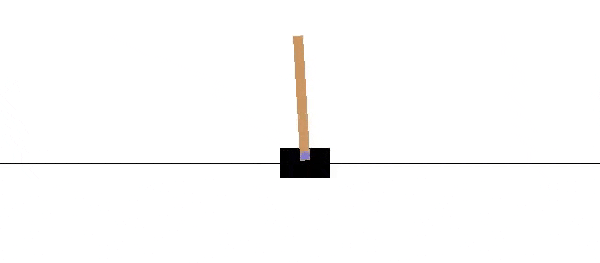

In this environment, a pole is attached by an un-actuated joint to a cart, which moves along a frictionless track. The system is controlled by applying a force of +1 or -1 to the cart. The pendulum starts upright, and the goal is to prevent it from falling over. A reward of +1 is provided for every timestep that the pole remains upright. The episode ends when the pole is more than 15 degrees from vertical, or the cart moves more than 2.4 units from the center. The episode also ends after 200 timesteps for `CartPole-v0` and 500 timesteps for CartPole-v1.

## Environment Description
(adapted from https://github.com/openai/gym/wiki/CartPole-v0)

## States
4 continuous values

|Num|State name|Min|Max|
|---|----------|---|---|
| 0 |Cart Position |-2.4|2.4|
| 1 | Cart Velocity|-Inf|Inf|
|2|Pole Angle|~ -41.8°|~ 41.8°|
|3|Pole Velocity At Tip|-Inf|Inf|


## Actions
2 discrete actions

| Num | Action |
|-----|--------|
|0|Push cart to the left|
|1|Push cart to the right|


Note: The amount the velocity is reduced or increased is not fixed as it depends on the angle the pole is pointing. This is because the center of gravity of the pole increases the amount of energy needed to move the cart underneath it

## Reward
Reward is 1 for every step taken, including the termination step.

## Starting State
All states are assigned a uniform random value between ±0.05.


## Episode Termination

1. Pole Angle is more than ±12°
2. Cart Position is more than ±2.4 (center of the cart reaches the edge of the display)
3. Episode length is greater than 200 (500 for v1).

For development and debugging, it is useful to start with `CartPole-v0` because the episodes are shorter (200 timesteps). However, the system should be able to work on `CartPole-v1` (500 timesteps).

In [ ]:
#@title install dependencies
# remove ` > /dev/null 2>&1` to see what is going on under the hood
!pip install gymnasium pyvirtualdisplay
!apt-get install -y xvfb ffmpeg

In [ ]:
#@title import numpy and gym
import numpy as np
import gymnasium as gym

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

In [ ]:
#@title code to display animations
from gymnasium.wrappers import RecordVideo
import glob
import io
import base64
from IPython.display import HTML
from IPython import display as ipythondisplay

## modified from https://colab.research.google.com/drive/1flu31ulJlgiRL1dnN2ir8wGh9p7Zij2t#scrollTo=TCelFzWY9MBI

def show_video():
  mp4list = glob.glob('/content/video/*.mp4')
  if len(mp4list) > 0:
    mp4 = mp4list[0]
    video = io.open(mp4, 'r+b').read()
    encoded = base64.b64encode(video)
    ipythondisplay.display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
  else:
    print("Could not find video")


def wrap_env(env):
  env = RecordVideo(env, '/content/video')
  return env


In [ ]:
#@title set up virtual display
from pyvirtualdisplay import Display

display = Display(visible=0, size=(1400, 900))
display.start()

In [ ]:
#@title test virtual display

#@markdown If you see a video of a cart-pole fumbling about, setup is complete!
env = wrap_env(gym.make("CartPole-v0", render_mode='rgb_array'))

observation, info = env.reset()
for i in range(10):
    env.render()
    obs, rew, term, trunc, info = env.step(env.action_space.sample() )
    if term or trunc:
      break;

env.close()
print('Loading video...')
show_video()

# Question 1: Random and Naive Agents
Before doing any RL, we are going to get familiar with the environment. First, you can use the `NaiveAgent`, which is already implemented. You can change the agent with the selector in the last cell. There, you can also change the environment used. You can try [similar environments](https://gym.openai.com/envs/#classic_control) from OpenAI Gym.

Note that `NaiveAgent` does not learn and its policy is very simple, but it is better than doing nothing.

* Run `CartPole-v0` and figure out what the policy is doing.

This is called bang-bang control, and it is the simplest controller that can be designed. This is the kind of controller that a thermostat uses.

Next, you should implement a random policy. The policy should behave randomly independently of the state of the system. This is the kind of policy that should be called for exploration if we used an epsilon-greedy policy.

* Implement the policy method for the `RandomAgent` class.

Note that you don’t need to implement anything else because `RandomAgent` does not learn. The `NaiveAgent` should be able to outperform the `RandomAgent`, even with such a simple policy.


In [ ]:
#@title Random agent class
#@markdown you need to implement `forward()`
class RandomPolicy(nn.Module):
    '''Agent that always follows a random policy.'''

    def __init__(self, obs_dim, n_actions):
        super(RandomPolicy, self).__init__()

    def forward(self, state):
        '''Returns a torch tensor vector with the probability for each action.
        All the returned values must add to 1.
        '''
        # *** YOUR CODE HERE ***
        probs = torch.tensor([...])
        return probs

In [ ]:
#@title Naive agent class
#@markdown It already implements bang-bang control
class NaivePolicy(nn.Module):
    '''Agent that uses a simple bang-bang controller.'''
    def __init__(self, obs_dim, n_actions):
        super(NaivePolicy, self).__init__()

    def forward(self, state):
        if state[2] < 0:
            return torch.tensor([1, 0])
        else:
            return torch.tensor([0, 1])

# Question 2: Linear Agent
Now we are going to implement our first agent using policy gradient. You need to complete the following code where you find:

`# *** YOUR CODE HERE ***`.

First, we need to initialize the neural network layers for the policy in the `__init__` method. Pytorch will already initialize the weights to a random value. In this case, it is important that the initial value is random, as for example, an initialization to 0 will result in a useless policy.

## Policy:
We are going to use a softmax linear policy. Remember that the equation is:

$$
  \pi_\theta (a|x) = \frac{e^{\phi(x,a)^T \theta}}{\sum_b e^{\phi(x,b)^T \theta}}
$$

In the `forward` method, this can be achieved using the `Linear` and `Softmax` layers from Pytorch. Check the documentation.

The input features are directly the state times an indicator function for the action. Another way to see the features is that the policy is actually the combination of two different functions: one for the probability of the left action and one for the probability of the right action, each with a different set of parameters.

That is, the policy can be written as:

$$ p(a_t = left| x_t = X) \propto e^{X_0\theta_0+\ldots+X_3\theta_3} $$
$$ p(a_t = right| x_t = X) \propto e^{X_0\theta_4+\ldots+X_3\theta_7} $$


where X is the value of the state vector at that moment. As you can see, with this policy, the number of parameters is `n_states * n_actions`. Remember that the symbol $\propto$ means proportional, because we are computing only the numerator of the policy.

For out implementation, we can use our scheme for a single layer neural network with a softmax output. Check the example for [MLP classification](https://colab.research.google.com/drive/1en-qsQBARZRiCRBWypfMflPVQnRIo89N?usp=sharing) which uses a similar architecture, also using Pytorch.


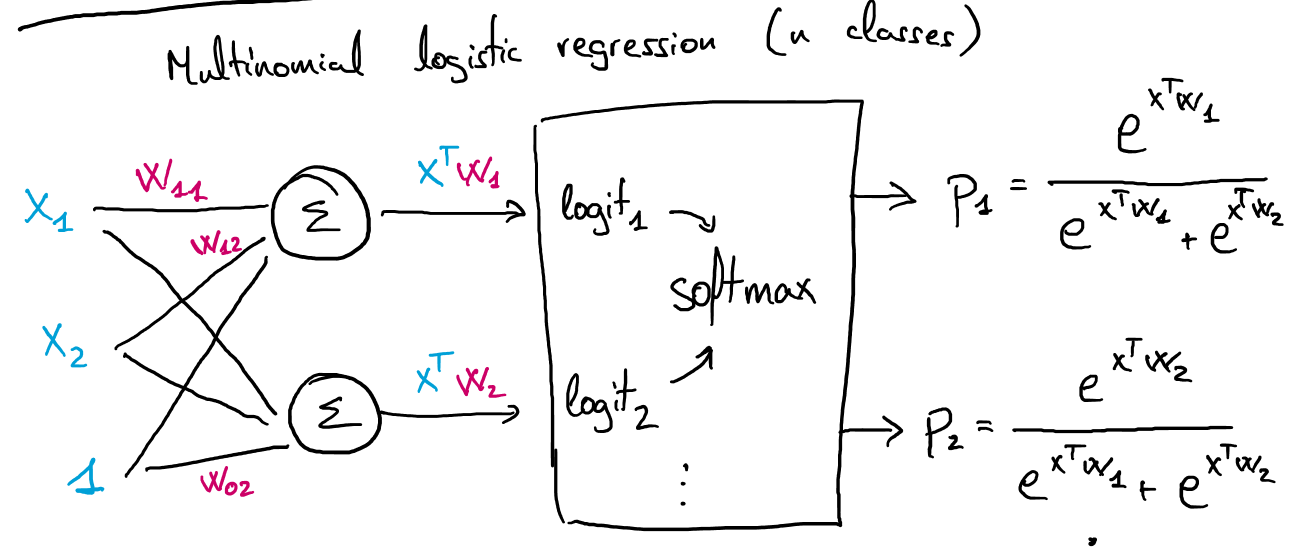



## Colecting data:
In the `run_episode` function, we need to be able to select the action that we take, either by sampling $a_t \sim \pi_\theta(a_t|x_t)$ or using the greedy policy $a_t = \arg \max_a \pi_\theta(a_t|x_t)$. In both cases, we can use the `Categorical` distribution from pytorch to get the probability distribution from the neural network output.

For training, we are going to use sampling, to improve exploration and for testing, we are going to use the greedy policy to be more efficient.

We also need to keep the log probability of the distribution in the `log_probs` and the `rewards` vectors to later compute the loss. For the log probabilities, you can also check the `Categoritcal` documentation.


## Policy update:
Using the `log_probs` and the `rewards` vectors computed before, in the `reinforce_loss` function it is your turn to compute the with those lists.

You should follow the REINFORCE algorithm:

* for each step t in episode do:

$$U_t \leftarrow \sum_{i=t+1}^T R_i$$
$$\theta \leftarrow \theta + \alpha \nabla_\theta \log \pi_\theta(a_t|x_t) U_t$$

Note that, Pytorch will already compute the gradien in `backwards`. Thus, the loss that we need to compute is:

$$\mathcal{L}(episode) =  \sum_{t=1}^{T} U_t \log \pi_\theta(a_t|x_t)$$

assuming that we are computing a minibatch with all the steps in the episode.

Important: do not worry about efficiency in this part. Grading would be based on the accuracy of the results and the technical quality of the report.

## Learning algorithm and learning rate:
You can achieve a decent performance with a constant learning rate and `SGD`. However, it might be tricky to find a good value. Instead, we are going to use a decaying sequence, that is, we make alpha with a smaller value after each episode. For that, we can use Pytorch schedulers like `StepLR` or `ExponentialLR` in `pytorch.optim.lr_scheduler`. Also, you should get better perfomance using advance gradient algorithms such as `Adam` in `pytorch.optim`.


In [ ]:
#@title Linear agent class
#@markdown you should complete where you find `***YOUR CODE HERE***`
class LinearPolicy(nn.Module):
    '''Agent that uses a softmax policy trained using REINFORCE.'''
    def __init__(self, obs_dim, n_actions):
        '''Define all the elements that you might need.

        Here you should define the layers that you are going to
        use in the "forward" method.
        Remember to consider the size of the input and the output.
        '''
        super(LinearPolicy, self).__init__()
        # *** YOUR CODE HERE ***


    def forward(self, x):
        # *** YOUR CODE HERE ***



In [ ]:
#@title Run Episode
#@markdown you should complete where you find `***YOUR CODE HERE***`

def run_episode(env, policy, train=True, render=False):
    obs, _ = env.reset()
    log_probs = []
    rewards = []

    done = False
    while not done:
        # Compute the distribution of all the actions based on
        # the current policy.
        #   -The input to the neural network must be a torch.tensor of
        # the correct size.
        #   -For the distribution use pytorch Categorical distribution
        #   -Check the MLP classification colab for reference.
        # *** YOUR CODE HERE ***

        dist = ...

        # If we train, we sample the action. If we
        if train:
            action = dist.sample()
        else:
            action = probs.argmax()

        # Append the current log_probabilities for the current action
        # in the log_probs list..
        # *** YOUR CODE HERE ***
        log_probs.append(...)

        # Take the step and collect reward and next observation.
        obs, reward, terminated, truncated, _ = env.step(action.item())
        rewards.append(reward)
        done = terminated or truncated

    if render:
        show_video()

    return rewards, log_probs

def reinforce_loss(rewards, log_probs, gamma):
    '''Update the parameters of the policy given an episode.

    log_probs and rewards contain a list of all the policy gradients
    and rewards collected at each timestep of the episode. You
    should use that to update the parameters of the policy as many
    times as possible.
    '''
    # *** YOUR CODE HERE ***




# ----- REINFORCE Algorithm -----
def reinforce(
    env_name="CartPole-v1",
    policy_name="naive",
    lr=1e-4,
    gamma=0.99,
    n_episodes=1000,
    eval_freq=100,
    render_mode='none',
    ):

    episode_train_rewards = []
    episode_eval_rewards = []

    env = wrap_env(gym.make(env_name, render_mode='rgb_array'))
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    if policy_name=='naive':
        policy = NaivePolicy(obs_dim, n_actions)
    elif policy_name == 'random':
        policy = RandomPolicy(obs_dim, n_actions)
    elif policy_name == 'linear':
        policy = LinearPolicy(obs_dim, n_actions)
    else:
        raise RuntimeError("Incorrect agent name!")

    # Define the optimizer and, if needed, a learning rate scheduler.
    # For example, you can use Adam or SGD in pytorch.optim.
    # and StepLR or ExponentialLR in pytorch.optim.lr_scheduler.
    # *** YOUR CODE HERE ***
    optimizer = None
    scheduler = None
    if policy_name == 'linear':
      optimizer = ...
      scheduler = ...


    for episode in range(n_episodes):
        rewards, log_probs = run_episode(env, policy)
        if policy_name == 'linear':
          loss = reinforce_loss(rewards, log_probs, gamma)

          # ----- Update policy -----
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

          # ----- Step the LR scheduler -----
          scheduler.step()

        # ----- Logging -----
        if episode % 100 == 0:
            total_reward = sum(rewards)
            current_lr = scheduler.get_last_lr()[0]
            print(f"Episode {episode+1}: reward = {total_reward:.1f}, loss = {loss.item():.1f}, lr = {current_lr:.6f}")

        episode_train_rewards.append(total_reward)

        if episode % eval_freq == 0:
            scores = []
            num_evals = 5
            # Run 5 evals and keep the mean
            for i in range(num_evals):
              render_evals = render_mode == 'all'
              rewards, _ = run_episode(env, policy, train=False, render=render_evals)
              scores.append(torch.sum(torch.tensor(rewards)))

            eval_reward = torch.mean(torch.tensor(scores))
            episode_eval_rewards.append(eval_reward)
            print(f"Episode {episode+1}: eval reward = {eval_reward:.1f}")




    if render_mode == 'final':
        rewards, _ = run_episode(env, policy, train=False, render=True)

    env.close()

    return episode_train_rewards, episode_eval_rewards


Now it is time to run the experiments with different agents, environments and duration. The history of all rewards obtained during training and eval is returned by the `reinforce` function.

Remember that the training trace is not representative because we are directly sampling from the stochastic policy to improve the exploration. For evaluation, we always choose the action with highest probability, resulting in a better performance.

For plotting, every `eval_freq` iterations, we are running 5 evaluation episodes and returning the average.

In [ ]:
#@title Configure your experiment
#@markdown choose your policy, enviroment, number of training episodes,
#@markdown evaluation frequency, learning rate, discount factor.

policy_name = 'linear' #@param ['naive', 'random', 'linear']
env_name = 'CartPole-v1' #@param ['CartPole-v0', 'CartPole-v1', 'Acrobot-v1']
learning_rate = 0.01 #@param {type: "number"}
discount_factor = 0.99 #@param {type: "number"}
num_episodes = 1000 #@param {type: "integer"}
eval_freq = 100 #@param {type: "integer"}

#@markdown `render_mode` shows a video for `all` eval, only a `final` video or `none`
render_mode = 'final' #@param ['none', 'all', 'final']

train_rewards, eval_rewards = reinforce(
    env_name=env_name,
    policy_name=policy_name ,
    lr=learning_rate,
    gamma=discount_factor,
    n_episodes=num_episodes,
    eval_freq=eval_freq,
    render_mode=render_mode,
    )

In [ ]:
#@title Plotting
#@markdown Let's plot both the training and evaluation results
import matplotlib.pyplot as plt
plt.plot(train_rewards)
plt.title('Training')
plt.figure()
plt.plot(eval_rewards, 'r')
plt.title('Evaluation')
plt.show()

Given the environment noise, you might find that sometimes training is much faster than others, without changing any parameter. That is something that we need to be careful. Ideally, **you should run the training multiple times** and plot the average traces with the correspoding error bars, although that is not required for this lab problem.